<a href="https://colab.research.google.com/github/Adityajakhar099/celebal-internship-assignments/blob/main/week2_Aditya_Jakhar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Uploading a CSV File

The following code snippet will allow you to upload a CSV file from your local machine to the Colab environment. Once uploaded, you can then load it into a pandas DataFrame for further analysis.

In [ ]:
from google.colab import files
import pandas as pd
import io

# Upload a CSV file
uploaded = files.upload()

# Get the filename of the uploaded file
for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')
  # Read the CSV file into a pandas DataFrame
  df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Display the first 5 rows of the DataFrame
print('\nFirst 5 rows of the uploaded data:')
display(df.head())

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv
User uploaded file "tesla_deliveries_dataset_2015_2025.csv" with length 224875 bytes

First 5 rows of the uploaded data:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
# Make sure 'tesla_deliveries_dataset_2015_2025.csv' is uploaded to your Colab environment
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

# View the first few rows and basic info
display(df.head())
display(df.info())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


None

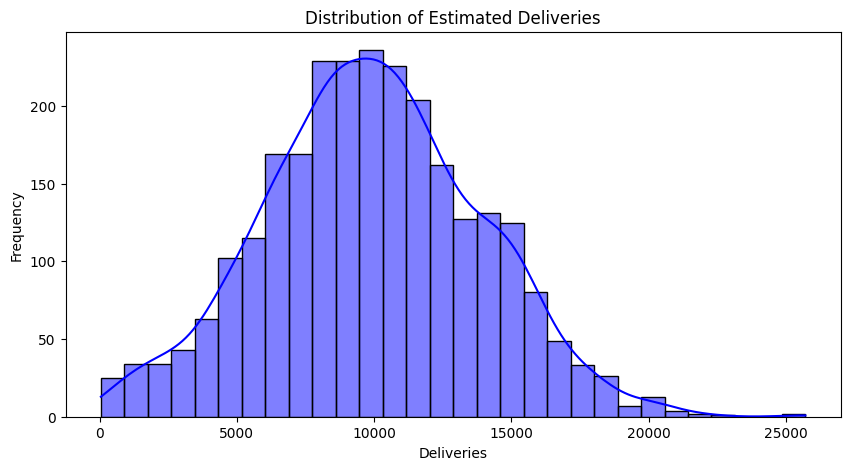

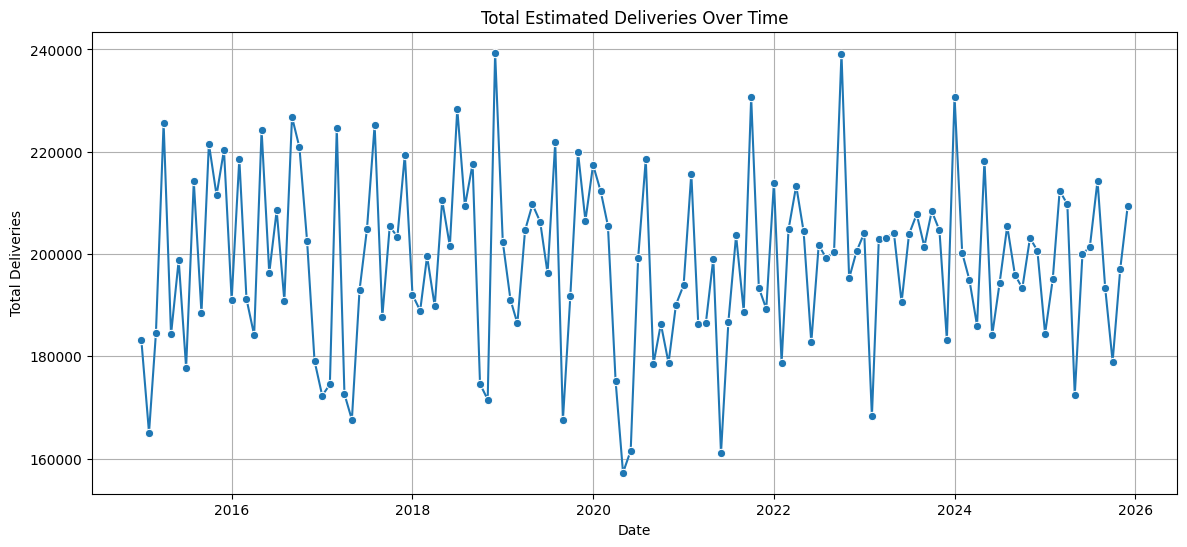

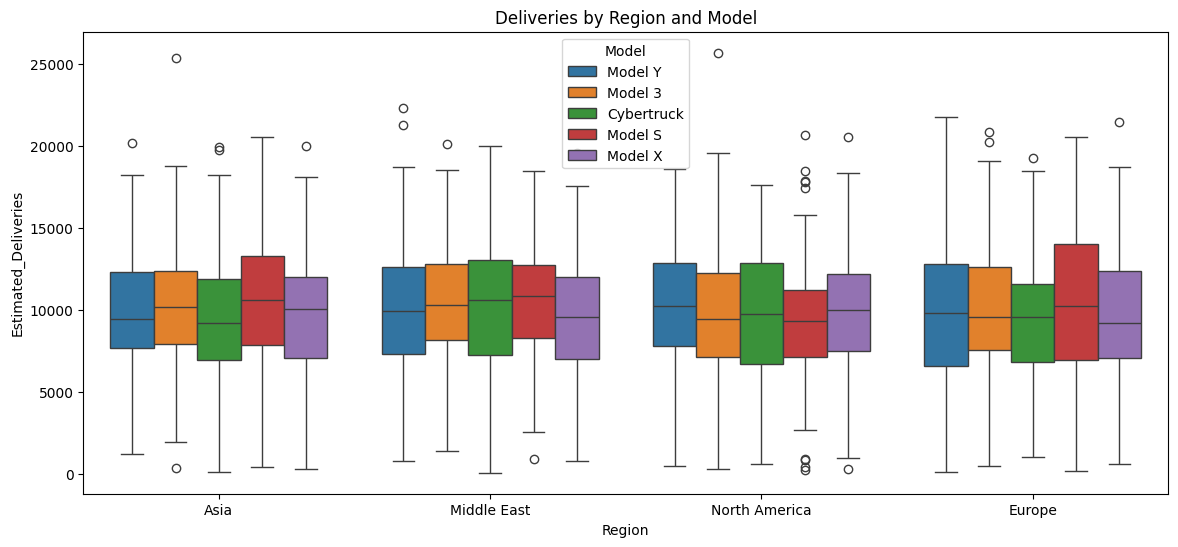

In [ ]:
# Preprocessing: Create a Datetime index for Time Series analysis
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df = df.sort_values('Date').reset_index(drop=True)

# EDA 1: Distribution of Estimated Deliveries
plt.figure(figsize=(10, 5))
sns.histplot(df['Estimated_Deliveries'], bins=30, kde=True, color='blue')
plt.title('Distribution of Estimated Deliveries')
plt.xlabel('Deliveries')
plt.ylabel('Frequency')
plt.show()

# EDA 2: Deliveries over Time
plt.figure(figsize=(14, 6))
df_time = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
sns.lineplot(data=df_time, x='Date', y='Estimated_Deliveries', marker='o')
plt.title('Total Estimated Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.grid(True)
plt.show()

# EDA 3: Deliveries by Region and Model
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Region', y='Estimated_Deliveries', hue='Model')
plt.title('Deliveries by Region and Model')
plt.show()

In [ ]:
# Create new insightful features
# 1. Price per unit of Range
df['Price_per_Range'] = df['Avg_Price_USD'] / (df['Range_km'] + 1) # +1 to avoid division by zero

# 2. Production to Delivery Ratio (efficiency metric)
df['Production_to_Delivery_Ratio'] = df['Production_Units'] / (df['Estimated_Deliveries'] + 1)

print("Features engineered successfully. Current columns:")
print(df.columns.tolist())

Features engineered successfully. Current columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date', 'Price_per_Range', 'Production_to_Delivery_Ratio']


In [ ]:
# Define features (X) and target (y)
# Dropping 'Date', 'Year', 'Month' as they are handled in Time Series
# Dropping 'CO2_Saved_tons' if we assume it's calculated post-delivery
X = df.drop(columns=['Estimated_Deliveries', 'Date', 'Year', 'Month', 'CO2_Saved_tons'])
y = df['Estimated_Deliveries']

# Identify categorical and numerical columns
categorical_features = ['Region', 'Model', 'Source_Type']
numeric_features = [col for col in X.columns if col not in categorical_features]

# Create a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the regression pipeline using Random Forest
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Hyperparameter Tuning using GridSearchCV
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5]
}

print("Starting Hyperparameter Tuning. This may take a moment...")
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model evaluation
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test R^2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

Starting Hyperparameter Tuning. This may take a moment...
Best Parameters: {'regressor__max_depth': 10, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Test R^2 Score: 0.9990
Test RMSE: 123.72


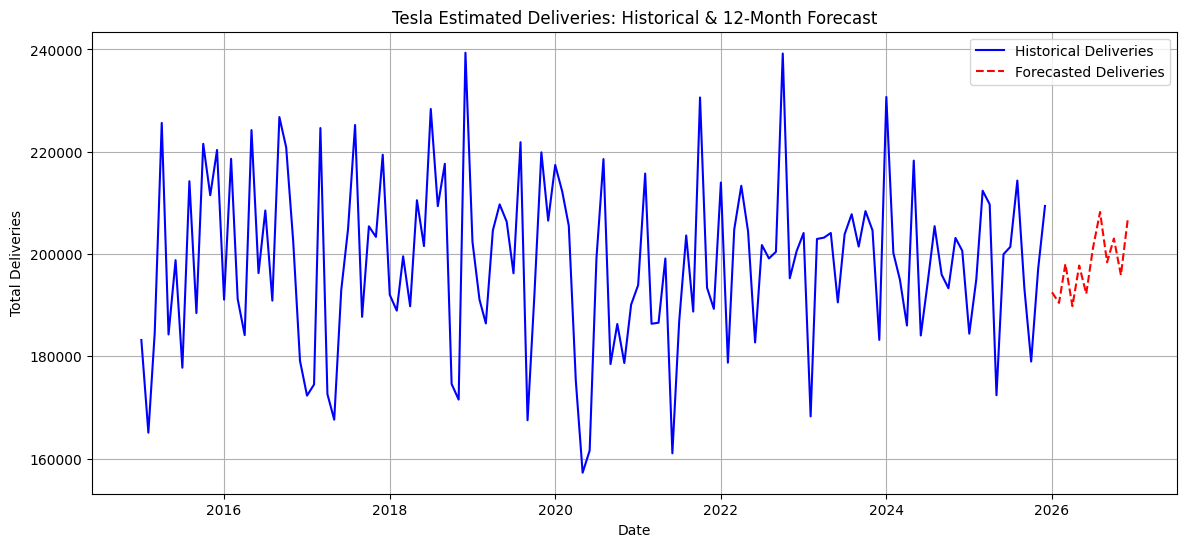

In [ ]:
# Aggregate data monthly for Time Series forecasting
ts_df = df.groupby('Date')['Estimated_Deliveries'].sum().asfreq('MS')

# Fit Holt-Winters Exponential Smoothing model
# Accounting for trend and potential yearly seasonality (12 periods)
ts_model = ExponentialSmoothing(
    ts_df,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

# Forecast the next 12 months (1 year)
forecast_steps = 12
forecast = ts_model.forecast(steps=forecast_steps)

# Plot Historical vs Forecasted Deliveries
plt.figure(figsize=(14, 6))
plt.plot(ts_df.index, ts_df.values, label='Historical Deliveries', color='blue')
plt.plot(forecast.index, forecast.values, label='Forecasted Deliveries', color='red', linestyle='--')

plt.title('Tesla Estimated Deliveries: Historical & 12-Month Forecast')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.legend()
plt.grid(True)
plt.show()